IMPORT DU FICHIER:

In [ ]:
from google.colab import files
filename = files.upload()

Saving 00036-00000006.wmd to 00036-00000006.wmd


Pour les temps

In [ ]:
%pip install ipython-autotime

Ecriture dans un fichier "resultat.txt"

In [ ]:
import time

def writef(resultat):
    # Ouvrir le fichier en mode d'écriture à la suite (append)
    with open("résultat.txt", "a") as fichier:
        # Écrire la valeur de la variable dans le fichier suivi d'un retour à la ligne
        fichier.write(str(resultat) + "\n")

PARSEUR ET DICTIONNAIRE:

In [ ]:
#définition de la valeur de k pour la résolution (taille max des cycles)

valeur_de_k = 2

filename = "00036-00000006.wmd" #à modifier quand on change d'instance
nomf = "00036-00000006.wmd" #à modifier quand on change d'instance
import numpy as np

lineCount = 0
nb_arete = 0
nb_couple = 0
nb_linetexte = 0

class Arete:
    def __init__(self,s):
        self.donneur = int(s[0])
        self.patient = int(s[1])
        self.poid = float(s[2])

liste_arete=[]

# on ouvre le fichier, puis on le stocke dans une structure f
with open(filename) as f:
  # on lit le fichier ligne par ligne
  for line in f:
    if (str(line.split(':')[0]) == '# NUMBER ALTERNATIVES'):
      x = line.split(":")
      nb_couple = int(x[1])
    elif (str(line.split(':')[0]) == '# NUMBER EDGES'):
      x = line.split(":")
      nb_arete = int(x[1])
      nb_linetexte = lineCount
    elif (lineCount > nb_linetexte + nb_couple and lineCount > lineCount + 1 - (nb_linetexte + nb_couple)):
      x = line.split(",")
      A = Arete(x)
      liste_arete.append(A)
    lineCount += 1

print("Colonne 1: Donneur")
print("Colonne 2: Patient")
print("Colonne 3: Poids")
print()
print("Nombre de paires patient-donneur: ",nb_couple)
print("Nombre d'arêtes du graphe: ",nb_arete)
print()
print("Données de l'instance",nomf, " :")
print()

# dictionnaire où l'on a dico["donneur"]=[liste des patients compatibles]
dico_graphe = {}
print()
list = []
for k in range(1, nb_couple+1):
  list = []
  for i in range(len(liste_arete)):
    if (liste_arete[i].donneur == k):
      list.append(liste_arete[i].patient)
  dico_graphe[k] = list

print(dico_graphe)

writef(filename)

Colonne 1: Donneur
Colonne 2: Patient
Colonne 3: Poids

Nombre de paires patient-donneur:  16
Nombre d'arêtes du graphe:  28

Données de l'instance 00036-00000006.wmd  :


{1: [], 2: [5, 7, 15], 3: [], 4: [5, 7, 15], 5: [1, 2, 3, 4, 6, 8, 9, 10, 12, 13, 14, 15, 16], 6: [], 7: [], 8: [], 9: [], 10: [7, 15], 11: [5, 15], 12: [], 13: [5, 7], 14: [], 15: [], 16: [5, 7, 15]}
time: 9.6 ms (started: 2023-11-27 17:26:49 +00:00)



Classe cycle:

In [ ]:
#classe cycle (pour y stocker les informations sur chaque cycle :
#les couples qu'il contient, le poids et la taille)

class Cycle:
    def __init__(self, list):
        self.cycle = list
        self.taille = len(list) #longueur du cycle
        poids = 0
        for i in range(len(list)):
          donneur = list[i] #les sommets: les donneurs
          patient = list[(i+1)%len(list)] #reste division euclidienne
          for k in range(len(liste_arete)):
            if(liste_arete[k].donneur == donneur
               and liste_arete[k].patient == patient):
              poids += liste_arete[k].poid
              break
        self.poids = poids

    def get_sommets(self):
        return self.cycle

    def __eq__(self, list):
      if (self.cycle == list):
        return True
      else:
        return False

time: 2.95 ms (started: 2023-11-27 17:26:55 +00:00)


**Génération** de cycles


In [ ]:
def parcours_en_profondeur(graphe, noeud, visites, pile, cycles,
                           taille_max_cycle):
  # Marquer le noeud courant comme visité
  visites[noeud] = True
  # Ajouter le noeud courant à la pile
  pile.append(noeud)
  #print("pile : ", pile)

  #on ne veut pas des cycles plus grand que taille_max _cycle
  if (len(pile) < taille_max_cycle + 1):
    #print("ok")
    # Pour chaque voisin du noeud courant
    for voisin in graphe[noeud]:
      #print("voisin", voisin)
      # Si voisin déjà dans la pile, cela signifie qu'il y a un cycle
      if voisin == pile[0] :
        # Créer la liste du cycle en utilisant la position du voisin dans la pile
        cycle = pile[:]
        #print(cycle)
        C = Cycle(cycle)
        cycles.append(C)
        #print( cycles[0].cycle )


      elif not visites[voisin]:
        # Sinon(si le voisin n'est pas dans la pile), appeler la fonction de parcours en profondeur pour le voisin
        parcours_en_profondeur(graphe, voisin, visites, pile, cycles, taille_max_cycle)

        # Enlever le dernier élément de la pile
        visites[pile[-1]] = False
        #print("pilepop : ", pile)
        pile.pop()
        #print("pilepop : ",pile.pop)
        # Marquer le noeud courant comme non visité
        #visites[noeud] = False


def trouver_cycles(graphe, taille_max_cycle):
# Initialiser un dictionnaire pour marquer les noeuds visités
  visites = {noeud: False for noeud in graphe}
# Initialiser une liste pour stocker les cycles
  cycles = []
  Noeud_départ_visite = []
# Pour chaque noeud dans le graphe
  for noeud in graphe:
    Noeud_départ_visite.append(noeud)
# Initialiser une pile pour l'algorithme de parcours en profondeur
    pile = []
# Appeler la fonction de parcours en profondeur
    parcours_en_profondeur(graphe, noeud, visites, pile, cycles, taille_max_cycle)
    #ici on note visiter tous les sommets dont on est parti pour faire le parcours en profondeur
    for noeud in graphe:
      if noeud in Noeud_départ_visite:
        visites[noeud] = True
      else:
        visites[noeud] = False
# Renvoyer les cycles et le nombre de cycles
  return cycles, len(cycles)

valeur_de_k = 5
#temps_debut = time.time()

A, nbA = trouver_cycles(dico_graphe, valeur_de_k)

#temps_fin = time.time()

#duree_execution = temps_fin - temps_debut

writef("cycles")
writef(nbA)
writef("temps")
#writef(duree_execution)

print("Nombre de cycles : ", nbA)

Nombre de cycles :  4
time: 7.63 ms (started: 2023-11-27 17:28:04 +00:00)


Résolution du problème en PLNE


In [ ]:
!pip install pulp
from pulp import *
gurobi_path=""
listSolvers(listSolvers(onlyAvailable = True))

C, nbC = trouver_cycles(dico_graphe, valeur_de_k)
print("nombre totale de cycle : ", nbC)
prob = LpProblem('Undefined_k', LpMaximize)

# Création des variables binaires x[u] pour chaque cycle u
x = LpVariable.dicts(name='x', indices = range(len(C)), cat='Binary')

# Ajout de l'objectif
prob += lpSum([x[u] * C[u].poids for u in range(len(C))])

# Ajout des contraintes et on utilise Ui ici
for i in range(nb_couple):
    Ui = []
    for u in range(len(C)):
        if i+1 in C[u].get_sommets():
            Ui.append(u)
    prob += lpSum([x[u] for u in Ui]) <= 1

# Résolution du problème
prob.solve(PULP_CBC_CMD(timeLimit=300, threads=4))

# Affichage de la solution
print("\n----------------------------------")
if prob.sol_status == LpSolutionOptimal:
    print("Status de la solution: OPTIMAL")
elif prob.sol_status == LpSolutionIntegerFeasible or prob.sol_status == LpSolutionNoSolutionFound:
    print("Status de la solution: TEMPS LIMITE ATTEINT")
elif prob.sol_status == LpSolutionInfeasible:
    print("Status de la solution: IRREALISABLE")
elif prob.sol_status == LpSolutionUnbounded:
    print("Status de la solution: NON BORNEE")
print("Temps de résolution (s) : ", value(prob.solutionTime))
print("----------------------------------")

solutionFound = False
if prob.sol_status == LpSolutionOptimal or prob.sol_status == LpSolutionIntegerFeasible:
    solutionFound = True
    print("Solution calculée")
    print("-> Valeur de la fonction objectif : ", value(prob.objective))

# Ecriture de la solution dans un fichier
if solutionFound:
    with open("solution.txt", "w") as f:
        for u in range(len(C)):
            if x[u].varValue == 1:
                sommets = C[u].get_sommets()
                f.write(f"Cycle {u+1} : {sommets}, poids = {C[u].poids}\n")
print("Nombre de cycles : ", nbC)
writef("PLNE")
writef(value(prob.objective))
writef(value(prob.solutionTime))

nombre totale de cycle :  4

----------------------------------
Status de la solution: OPTIMAL
Temps de résolution (s) :  0.008797883987426758
----------------------------------
Solution calculée
-> Valeur de la fonction objectif :  2.0
Nombre de cycles :  4
time: 8.69 s (started: 2023-11-27 19:07:42 +00:00)


In [ ]:
#Checker

def checker(Cycles, k):

  # Vérifie que chaque cycle a une taille inférieure ou égale à k.
  for u in range(len(Cycles)):
    if len(Cycles[u]) > k:
      return False

      # Vérifie que chaque paire de cycles est disjointe.
  for u in range(len(Cycles)):
    for i in range(u + 1, len(Cycles)):
      if set(Cycles[u]) & set(Cycles[i]):
        return False

  return True


#Sélectionne les cycles dans la solution
liste_Cycles = []
for u in range(len(C)): # C utilisé pour la résolution en PLNE
  if x[u].varValue == 1:
    liste_Cycles.append(C[u].cycle)

for u in range(len(liste_Cycles)):
  print(liste_Cycles[u])

#Affichage résultats
if checker(liste_Cycles, valeur_de_k):
    print("La solution est réalisable.")
else:
    print("La solution n'est pas réalisable.")


[5, 16]
La solution est réalisable.


Affichage du graphe orienté à l'écran

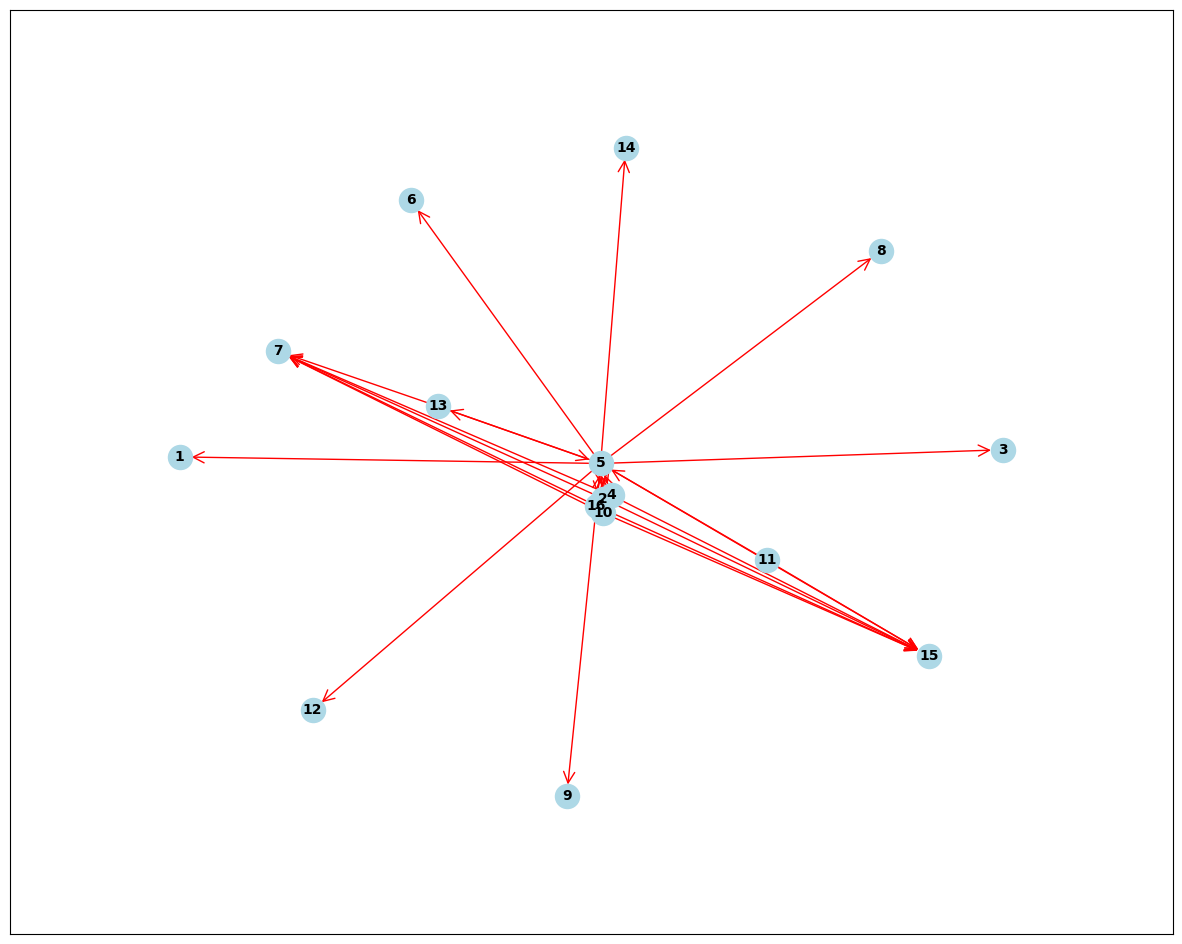

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Création d'un objet Graph orienté à partir du dictionnaire
graphe = nx.DiGraph(dico_graphe)

# Définition de la disposition des nœuds
position = nx.spring_layout(graphe)

# Tracé du graphe en couleur avec une taille de figure plus grande et des options de tracé améliorées
fig, ax = plt.subplots(figsize=(15, 12))
nx.draw_networkx(graphe, position, with_labels=True, node_color='lightblue', edge_color='red', arrowsize=20, arrowstyle='->', font_size=10, font_weight='bold')

# Définir les limites d'affichage pour un zoom plus approprié
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.set_xlim(xmin - 0.2, xmax + 0.2)
ax.set_ylim(ymin - 0.2, ymax + 0.2)

# Affichage du graphe
plt.show()

Le flot (k=infini)

E_i


In [ ]:
%load_ext autotime

def get_Ei(graph, i):
    Ei = []
    for node in graph:
        if i in graph[node]:
            Ei.append(node)
    return Ei

i = 3
Ui = get_Ei(dico_graphe, i)
print(Ui)
print(nb_couple)

[5]
16
time: 12.8 ms (started: 2023-11-27 14:53:27 +00:00)


S_i


In [ ]:
%load_ext autotime

def get_Si(graph, i):
    return graph[i]

i = 4
Si = get_Si(dico_graphe, i)
print(Si)
print(nb_couple)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
[5, 7, 15]
16
time: 4.95 ms (started: 2023-11-27 14:53:30 +00:00)


V

In [ ]:
%load_ext autotime
print(len(liste_arete))

def Poid_Arete(donneur, patient, liste_arete):
    poids = 0
    for i in range(len(liste_arete)):
        if (liste_arete[i].donneur == donneur) and (liste_arete[i].patient == patient):
            poids = liste_arete[i].poid
            break
    return poids

print(Poid_Arete(2, 4, liste_arete))

print(nb_couple)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
28
0
16
time: 1.58 ms (started: 2023-11-27 14:53:45 +00:00)


In [ ]:
from pulp import *
gurobi_path=""
listSolvers(listSolvers(onlyAvailable = True))

%load_ext autotime
#print(dico_graphe)
#print(nb_couple)
Si = []
Ei = []
couple_Si = []
couple_Ei = []

#liste des couples
V_list = [i for i in range(1, nb_couple+1)]

#liste des arêtes (orientées) du graphe
listArete = [(i, j) for i in V_list for j in V_list if j in dico_graphe[i]]

#le poid des arètes du graphe
poid_arete = np.zeros((nb_couple, nb_couple))
for i in range(1, nb_couple+1):
  for j in range(1,nb_couple+1):
    poid_arete[i-1][j-1] = Poid_Arete(i,j,liste_arete)

#construction des listes Si et Ei pour tout i E [0,nb_couple]
for i in V_list:
    Si.append(get_Si(dico_graphe, i))
    Ei.append(get_Ei(dico_graphe, i))
#print(Si)
#print(Ei)

#construction des listes des couples correspondant aux arètes entre le sommet i et les sommets de Si, et entre le sommet i et les sommets de Ei:
for i in V_list:
  list_coupleS = []
  list_coupleE = []
  for j in Si[i-1]:
    list_coupleS.append((i,j))
  couple_Si.append(list_coupleS)
  for j in Ei[i-1]:
    list_coupleE.append((j,i))
  couple_Ei.append(list_coupleE)

#print(couple_Si)
#print(couple_Ei)

# Modèle
prob = LpProblem("FlotMax", LpMaximize)

x = LpVariable.dicts("x", listArete, lowBound=0, upBound=1, cat="Integer")

#Fonction objectif
prob += lpSum([x[(i, j)] * poid_arete[i-1][j-1] for (i, j) in listArete])

# Contraintes, on crée des listes pour Si et Ei des liste ([S1, S2, ....])

for i in range(nb_couple):
  prob += lpSum([x[(u, j)] for (u,j) in couple_Si[i]]) <= 1, f"Contrainte1_{i}"
  prob += lpSum([x[(a, b)] for  (a, b) in couple_Si[i]]) == lpSum([x[(c, d)] for  (c, d) in couple_Ei[i]]), f"Contrainte3_{i}"

prob.solve(PULP_CBC_CMD(timeLimit=30, threads=1))

# Affichage de la solution
print("\n----------------------------------")
if prob.sol_status == LpSolutionOptimal:
    print("Status de la solution: OPTIMAL")
elif prob.sol_status == LpSolutionIntegerFeasible or prob.sol_status == LpSolutionNoSolutionFound:
    print("Status de la solution: TEMPS LIMITE ATTEINT")
elif prob.sol_status == LpSolutionInfeasible:
    print("Status de la solution: IRREALISABLE")
elif prob.sol_status == LpSolutionUnbounded:
    print("Status de la solution: NON BORNEE")
print("Temps de résolution (s) : ", value(prob.solutionTime))
print("----------------------------------")

with open("solutionflot.txt", "w") as f:
  if x.get((i, j)) is not None:
    f.write(f"x[{i},{j}] = {x[(i, j)].value()}\n")
  else:
    f.write(f"x[{i},{j}] = 0\n")

writef("flot")
writef(value(prob.objective))
writef(value(prob.solutionTime))

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

----------------------------------
Status de la solution: OPTIMAL
Temps de résolution (s) :  0.008480310440063477
----------------------------------
time: 23 ms (started: 2023-11-27 14:54:23 +00:00)


1) Transfert de notre instance en graphe non orienté


In [ ]:
%load_ext autotime

list_arete = []
list_tmp = []
for k in range (1, nb_couple+1):
  liste_som_adj = dico_graphe[k]
  for i in range (len(liste_som_adj)):
    if (k in dico_graphe[liste_som_adj[i]] and ([liste_som_adj[i], k] in list_tmp) == False):
      list_tmp.append([k,liste_som_adj[i]])
      cycle = Cycle([k,liste_som_adj[i]])
      list_arete.append(cycle)

print("Liste d'arêtes du matching : ")

#création des ensembles delta(i):
list_delta =[]
list_tmp = []
for i in range (1, nb_couple+1):
  list_tmp = []
  for k in range(len(list_arete)):
    if (i == list_arete[k].cycle[0] or i == list_arete[k].cycle[1]) :
      list_tmp.append(k)
  list_delta.append(list_tmp)

#print(list_delta)
#print(len(list_delta))
#print(len(list_arete))

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Liste d'arêtes du matching : 
time: 23.5 ms (started: 2023-11-27 14:54:43 +00:00)


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

time: 468 µs (started: 2023-11-27 14:55:55 +00:00)


Matching (pour k=2)

In [ ]:
from pulp import *
gurobi_path=""
listSolvers(listSolvers(onlyAvailable = True))

%load_ext autotime

print(len(list_arete))
print(len(list_delta))
print(list_delta)

prob = LpProblem('k=2', LpMaximize)

# Création de x_e pour chaque cycle A
x = LpVariable.dicts(name='x', indices =range(len(list_arete)), cat='Binary')

# Objectif
prob += lpSum([x[e]*list_arete[e].poids for e in range(len(list_arete))])

#Contraintes
for j in range(len(list_delta)):
    prob += lpSum([x[e] for e in list_delta[j]]) <= 1

# Résolution du problème (Temps limite 30s, pocéseur utilisé : 1)
prob.solve(PULP_CBC_CMD(timeLimit=30, threads=1))

# Affichage de la solution
print("\n----------------------------------")
if prob.sol_status == LpSolutionOptimal:
    print("Status de la solution: OPTIMAL")
elif prob.sol_status == LpSolutionIntegerFeasible or prob.sol_status == LpSolutionNoSolutionFound:
    print("Status de la solution: TEMPS LIMITE ATTEINT")
elif prob.sol_status == LpSolutionInfeasible:
    print("Status de la solution: IRREALISABLE")
elif prob.sol_status == LpSolutionUnbounded:
    print("Status de la solution: NON BORNEE")
print("Temps de résolution (s) : ", value(prob.solutionTime))
print("----------------------------------")

solutionFound = False
if prob.sol_status == LpSolutionOptimal or prob.sol_status == LpSolutionIntegerFeasible:
    solutionFound = True
    print("Solution calculée")
    print("-> Valeur de la fonction objectif : ", value(prob.objective))

# Ecriture de la solution dans un fichier
if solutionFound:
    with open("solutionmatching.txt", "w") as f:
        for u in range(len(list_arete)):
            if x[u].varValue == 1:
                sommets = list_arete[u].cycle
                f.write(f"Cycle {u+1} : {sommets}, poids = {list_arete[u].poids}\n")

writef("matching")
writef(value(prob.objective))
writef(value(prob.solutionTime))

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
4
16
[[], [0], [], [1], [0, 1, 2, 3], [], [], [], [], [], [], [], [2], [], [], [3]]

----------------------------------
Status de la solution: OPTIMAL
Temps de résolution (s) :  0.009288787841796875
----------------------------------
Solution calculée
-> Valeur de la fonction objectif :  2.0
time: 25.2 ms (started: 2023-11-27 14:54:54 +00:00)
